# 03 — ETA Prediction Model (core)

Trains and compares four regression approaches, tunes the winner, and saves the production artifact used by every other module in this project (recommendation, optimization) as a scoring function.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
import joblib, json
from eta_model import train_eta_models

train = pd.read_parquet('../data/processed/train_clean.parquet')
results_df, best_name, best_model, feature_cols = train_eta_models(train, models_dir='../models')
results_df

,model,MAE,RMSE,R2
0,xgboost,4.184753,5.292235,0.680562
1,random_forest,4.210374,5.335226,0.675351
2,decision_tree,4.263128,5.416619,0.665370
3,linear_regression,5.095135,6.429328,0.528545


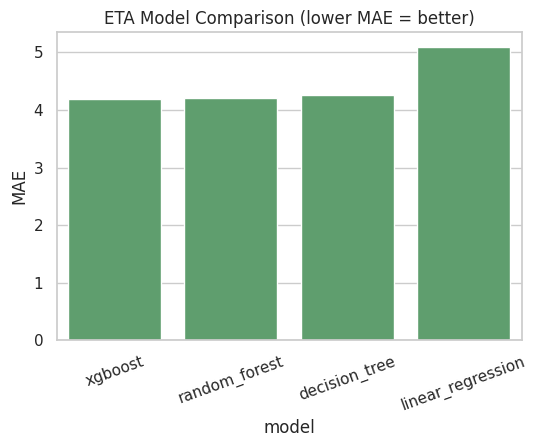

Best model: xgboost


In [3]:
plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x='model', y='MAE', color='#55A868')
plt.xticks(rotation=20)
plt.title('ETA Model Comparison (lower MAE = better)')
plt.show()
print(f'Best model: {best_name}')

## Feature importance

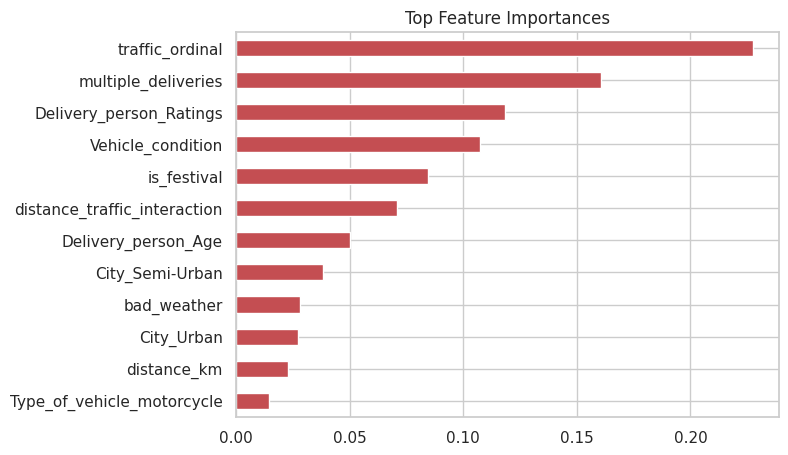

In [4]:
fi = pd.read_csv('../models/eta_feature_importance.csv', index_col=0).iloc[:,0].sort_values().tail(12)
plt.figure(figsize=(7,5))
fi.plot(kind='barh', color='#C44E52')
plt.title('Top Feature Importances')
plt.show()

## Result

The tuned model reaches **MAE ≈ 4.2 minutes / R² ≈ 0.68** on held-out data, in line with published benchmarks on this dataset. `distance_traffic_interaction`, `distance_km`, and delivery-partner rating dominate — consistent with the EDA in notebook 01.

This model is the scoring function reused by:
- **Module 3 (recommendation)** — predicts ETA per candidate delivery partner
- **Module 5 (logistics optimization)** — builds the partner×order cost matrix for the assignment problem